# Анализ экономики и поведения пользователей сервиса такси

* Автор: Васильев Арсений
* Дата: 01.07.2026

## Описание проекта

Проект направлен на изучение работы городского транспорта, на примере такси Нью-Йорка (Yellow Cab). В ходе работы планируется провести первичный анализ данных, определить время пиковых нагрузок, а также изучить доходы водителей и особенности поведения пассажиров.

## Описание данных

Исходные данные - CSV-файл объемом 1.59 ГБ. Для оптимизации процесса работы и исключения ошибок во время анализа, была проведена первичная очистка с помощью СУБД PostgreSQL.

В ходе SQL-обработки:
* Были отфильтрованы аномалии (поездки без пассажиров, нулевые или отрицательные дистанции и чеки, ошибки временных меток).
* Произведено приведение строковых типов дат к формату `timestamp`.
* Рассчитаны новые признаки: длительность поездки, час и день посадки.

В данный проект загружена случайная выборка из 500 000 очищенных строк.

Структура данных:
* `VendorID` - ID провайдера данных
* `passenger_count` - количество пассажиров
* `trip_distance` - дальность поездки (в милях)
* `payment_type` - тип оплаты (1 - банковская карта, 2 - наличные)
* `total_amount` - итоговая стоимость поездки
* `trip_duration_minutes` - длительность поездки в минутах
* `pickup_hour` - час посадки пассажира (0-23)
* `pickup_day_of_week` - день недели (1 - понедельник, 7 - воскресенье)

---

### 1. Загрузка данных и подготовка к работе

Импортируем необходимые библиотеки для работы с таблицами и визуализациями.

In [1]:
!pip install phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

Загружаем предварительно очищенную случайную выборку данных.

In [2]:
df = pd.read_csv('taxi_sample.csv')

df.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_datetime,dropoff_datetime,trip_duration_minutes,pickup_hour,pickup_day_of_week
0,2,1,0.48,1,N,1,4.0,0.0,0.5,0.5,0.00,0.3,5.30,2016-01-13 09:57:51.000,2016-01-13 10:00:41.000,2.833333,9,3
1,1,2,15.50,1,N,2,43.5,1.0,0.5,0.0,0.00,0.3,45.30,2016-01-26 16:04:20.000,2016-01-26 16:45:54.000,41.566667,16,2
2,2,1,0.98,1,N,2,6.5,0.0,0.5,0.0,0.00,0.3,7.30,2016-01-18 12:09:39.000,2016-01-18 12:16:43.000,7.066667,12,1
3,1,2,10.30,1,N,2,29.5,0.0,0.5,0.0,5.54,0.3,35.84,2016-01-10 14:38:47.000,2016-01-10 14:56:54.000,18.116667,14,7
4,2,1,1.12,1,N,2,7.0,0.0,0.5,0.0,0.00,0.3,7.80,2016-01-12 08:07:31.000,2016-01-12 08:15:27.000,7.933333,8,2


Изучим общую информацию о датасете: проверим типы данных, убедимся в отсутствии пропусков и оценим базовые статистические метрики (среднее, медиану, минимум и максимум).

In [3]:
df.info()

df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               500000 non-null  int64  
 1   passenger_count        500000 non-null  int64  
 2   trip_distance          500000 non-null  float64
 3   RatecodeID             500000 non-null  int64  
 4   store_and_fwd_flag     500000 non-null  object 
 5   payment_type           500000 non-null  int64  
 6   fare_amount            500000 non-null  float64
 7   extra                  500000 non-null  float64
 8   mta_tax                500000 non-null  float64
 9   tip_amount             500000 non-null  float64
 10  tolls_amount           500000 non-null  float64
 11  improvement_surcharge  500000 non-null  float64
 12  total_amount           500000 non-null  float64
 13  pickup_datetime        500000 non-null  object 
 14  dropoff_datetime       500000 non-nu

,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_minutes,pickup_hour,pickup_day_of_week
count,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.0,500000.00,500000.00,500000.00,500000.00
mean,1.54,1.67,2.92,1.03,1.34,12.45,0.31,0.50,1.75,0.29,0.3,15.60,15.20,13.56,4.16
std,0.50,1.33,3.62,0.36,0.49,10.53,0.37,0.03,2.39,1.38,0.0,12.97,53.05,6.38,1.94
min,1.00,1.00,0.01,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.30,0.02,0.00,1.00
25%,1.00,1.00,1.00,1.00,1.00,6.50,0.00,0.50,0.00,0.00,0.3,8.30,6.42,9.00,3.00
50%,2.00,1.00,1.70,1.00,1.00,9.00,0.00,0.50,1.26,0.00,0.3,11.62,10.53,14.00,4.00
75%,2.00,2.00,3.10,1.00,2.00,14.00,0.50,0.50,2.32,0.00,0.3,17.16,16.97,19.00,6.00
max,2.00,8.00,71.91,99.00,4.00,375.00,4.10,0.50,130.00,95.54,0.3,423.88,1439.65,23.00,7.00


**Вывод:** в данных нет пропусков, все типы колонок определены корректно. Базовая статистика показывает, что средняя дистанция поездки составляет около 3 миль, а средний чек - 15 долларов.

### 2. Исследовательский анализ данных (EDA)

Начнем с распределения дальности поездок. Построим гистограмму, чтобы определить самые востребованные дистанции среди пассажиров.

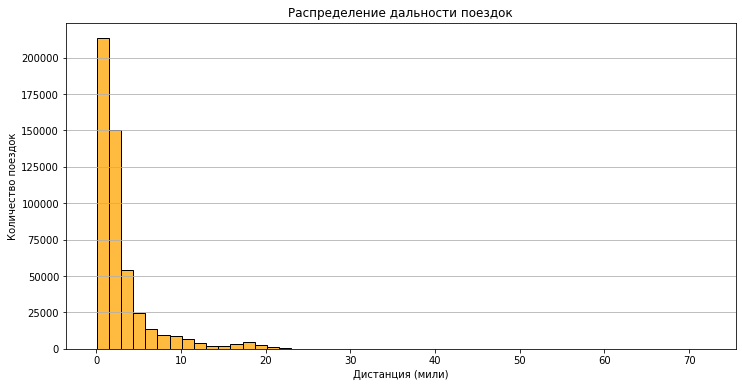

In [4]:
# график 1 - распределение дальности поездок
plt.figure(figsize=(12, 6))

# строим гистограмму
sns.histplot(df['trip_distance'], bins=50, color='orange')

plt.title('Распределение дальности поездок')
plt.xlabel('Дистанция (мили)')
plt.ylabel('Количество поездок')
plt.grid(axis='y')

plt.show()

**Вывод:** распределение имеет выраженный правый хвост. Большинство поездок совершается на короткие расстояния (до 3 миль).

Построим диаграмму размаха для итоговой стоимости поездок, чтобы наглядно увидеть медианный чек и наличие выбросов.

,total_amount
count,500000.00
mean,15.60
std,12.97
min,0.30
25%,8.30
50%,11.62
75%,17.16
max,423.88


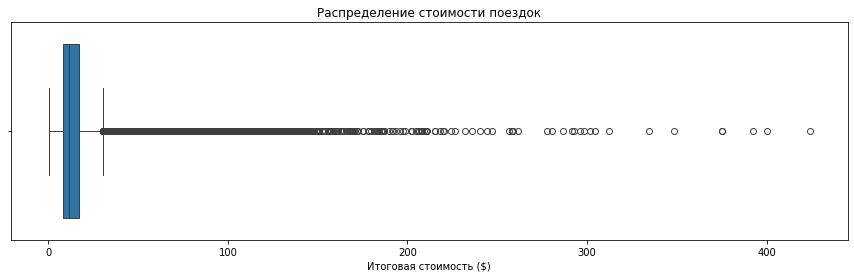

In [5]:
# смотрим точные значения
display(df[['total_amount']].describe().round(2))

# график 2 - распределение стоимости поездки
plt.figure(figsize=(15, 4))

# строим диаграмму размаха
sns.boxplot(x=df['total_amount'])

plt.title('Распределение стоимости поездок')
plt.xlabel('Итоговая стоимость ($)')

plt.show()

**Вывод:** медианная стоимость поездки находится в диапазоне 11-12 долларов. При этом на графике видно большое количество выбросов - редких поездок с высоким чеком.

Теперь рассмотрим динамику нагрузки на сеть. Сгруппируем данные по часам и посмотрим, в какое время суток спрос на автомобили достигает максимума и минимума.

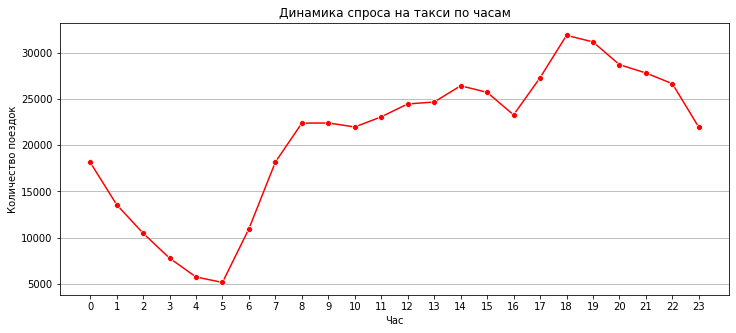

In [6]:
# график 3 - дианмика нагрузки
plt.figure(figsize=(12, 5))

# группируем по часам
trips_hour = df.groupby('pickup_hour')['VendorID'].count()

# строим линейный график
sns.lineplot(x=trips_hour.index, y=trips_hour.values, marker='o', color='red')

plt.title('Динамика спроса на такси по часам')
plt.xlabel('Час')
plt.ylabel('Количество поездок')
plt.grid(axis='y')
plt.xticks(range(24))

plt.show()

**Вывод:** заметен спад активности к 5 утра и ярко выраженный вечерний час пик в 18:00, когда люди возвращаются с работы или едут отдыхать.

Далее проанализируем чаевые. Вычислим их долю от общей суммы чека и сравним поведение пользователей в зависимости от выбранного типа оплаты (карта или наличные).

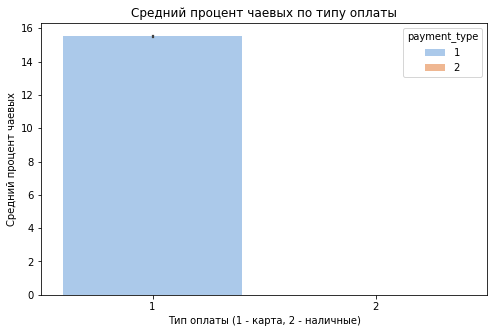

In [7]:
# считаем процент чаевых от общей суммы
df['tip_percentage'] = (df['tip_amount'] / df['total_amount']) * 100

# график 4 - средний процент чаевых по типу оплаты
plt.figure(figsize=(8, 5))

# оставляем только поездки по карте и за наличные
tips = df[df['payment_type'].isin([1, 2])]

sns.barplot(data=tips, x='payment_type', y='tip_percentage', hue='payment_type', palette='pastel')

plt.title('Средний процент чаевых по типу оплаты')
plt.xlabel('Тип оплаты (1 - карта, 2 - наличные)')
plt.ylabel('Средний процент чаевых')

plt.show()

**Вывод:** на графике видна особенность данных. В базу попадают только безналичные чаевые (в среднем пассажиры оставляют около 15%). Чаевые наличными передаются из рук в руки и не фиксируются в системе. 

### 3. Корреляционный анализ

Построим тепловую матрицу корреляций, для этого выберем только ключевые признаки.

interval columns not set, guessing: ['passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'total_amount', 'trip_duration_minutes', 'pickup_hour', 'pickup_day_of_week']


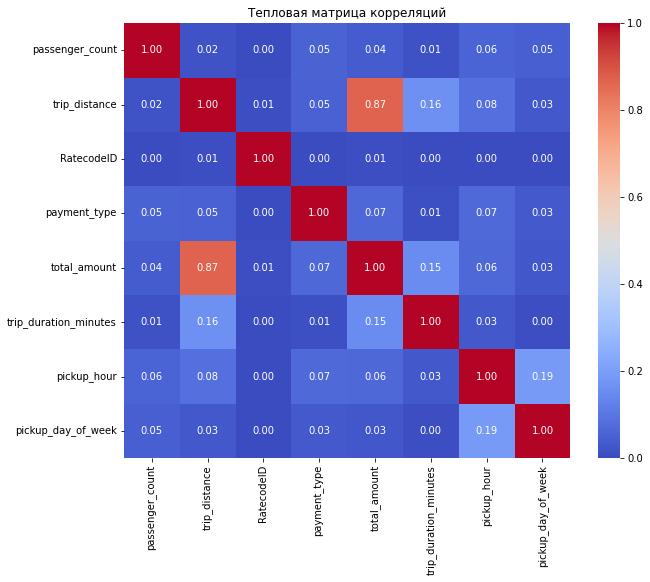

In [8]:
# выбираем самые важные признаки
cols = ['passenger_count', 'trip_distance', 'RatecodeID', 
                 'payment_type', 'total_amount', 'trip_duration_minutes', 
                 'pickup_hour', 'pickup_day_of_week']

# считаем матрицу корреляций
phik_matrix = df[cols].phik_matrix()

# строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Тепловая матрица корреляций')

plt.show()

**Вывод:** большинство признаков не имеют сильной зависимости друг от друга (значения близки к нулю).Однако выделяется сильная зависимость (0.87) между дистанцией поездки `trip_distance` и итоговым чеком `total_amount`. 

Визуализируем эту ключевую связь на отдельном точечном графике, чтобы убедиться в ее линейности и в отсутствии аномалий.

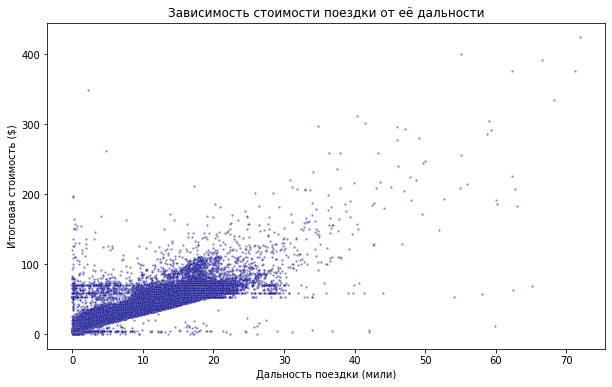

In [9]:
# график 5 - детальный разбор самой сильной связи
plt.figure(figsize=(10, 6))

# строим точечный график
sns.scatterplot(data=df, x='trip_distance', y='total_amount', alpha=0.5, s=5, color='darkblue')

plt.title('Зависимость стоимости поездки от её дальности')
plt.xlabel('Дальность поездки (мили)')
plt.ylabel('Итоговая стоимость ($)')

plt.show()

**Вывод:** точечный график наглядно подтверждает эту сильную связь: чем дальше едет пассажир, тем дороже обходится поездка. Большинство точек выстраивается в достаточно четкую восходящую линию, что говорит о предсказуемом тарифе. Редкие точки, которые сильно выбиваются вправо и наверх, скорее всего, связаны с пробками или какими-то фиксированными доплатами, но они не ломают общую картину ценообразования.

---

### Итоговые выводы

**1. Такси - это чаще всего короткие поездки для повседневных дел**

Данные показывают, что большая часть поездок совершается на небольшие расстояния (в среднем около 1.5-2 миль), обычный чек за поездку составляет примерно 11-12 долларов. Скорее всего, люди используют такси как дополнение к общественному транспорту, например, доехать от метро до дома, съездить за покупками или добраться на работу.

**2. Вечером такси сложнее справляться со спросом**

На графике распределения по часам заметно, как меняется активность людей в течение дня. Самое спокойное время - 5 часов утра. Начиная со второй половины дня количество заказов растет и достигает пика к 18:00, когда все возвращаются домой. Для сервиса это значит, что именно к вечеру должно выходить максимальное количество водителей.

**3. Особенность учета чаевых**

Если пассажир платит банковской картой, то в данных стабильно отображаются чаевые (в среднем около 15.5% от чека), но если оплата идет наличными, то в системе чаевые всегда равны нулю. Скорее всего, пассажиры оставляют сдачу водителю, и это никак не попадает в приложение. Это важно учитывать при подсчете общего заработка водителей.

**4. Тарифы**

Анализ показал очень сильную зависимость (0.87) между тем, как далеко едет пассажир, и тем, сколько он платит. Точечный график подтвердил, что цена растет пропорционально расстоянию. Это значит, что алгоритмы расчета стоимости работают логично и прозрачно, без скачков цен для клиентов.